# QAOA on Rigetti Hardware (via QCS)

This notebook demonstrates the **Quantum Approximate Optimization Algorithm (QAOA)** solving a **Max-Cut** problem using PennyLane with Rigetti devices.

### Device Options
| Device string | Where it runs |
|---|---|
| `'rigetti.qvm'` | Local quantum virtual machine (simulator) |
| `'rigetti.qpu'` | Real Rigetti QPU via QCS (requires account) |

**Prerequisites (local simulation):** Start QVM and quilc services:  
```bash
docker run --rm -d -p 5000:5000 rigetti/qvm -S
docker run --rm -d -p 5555:5555 rigetti/quilc -P -S
```

In [1]:
import pennylane as qml
from pennylane import qaoa
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize

print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.44.0


## 1. Define the Problem Graph (Max-Cut)

Max-Cut: partition graph nodes into two sets to maximise the number of edges between them.

/var/folders/cn/1yhq64td3_j1p23cdwjs4xsh0000gn/T/ipykernel_89160/1596854274.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


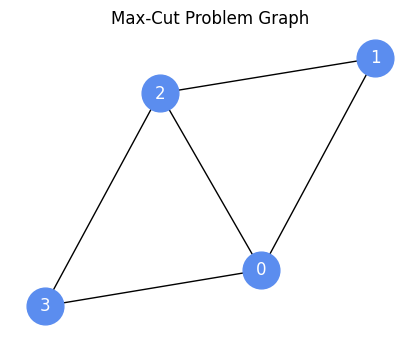

Nodes: [0, 1, 2, 3]  |  Edges: [(0, 1), (0, 3), (0, 2), (1, 2), (2, 3)]


In [2]:
# --- Build a simple 4-node graph ---
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]   # modify as needed
G = nx.Graph()
G.add_edges_from(edges)
n_wires = len(G.nodes)

plt.figure(figsize=(4, 3))
nx.draw(G, with_labels=True, node_color='#5B8DEF', font_color='white', node_size=700)
plt.title("Max-Cut Problem Graph")
plt.tight_layout()
plt.show()
print(f"Nodes: {list(G.nodes)}  |  Edges: {list(G.edges)}")

## 2. Build the QAOA Cost and Mixer Hamiltonians

In [3]:
cost_h, mixer_h = qaoa.maxcut(G)
print("Cost Hamiltonian:")
print(cost_h)
print("\nMixer Hamiltonian:")
print(mixer_h)

Cost Hamiltonian:
0.5 * (Z(0) @ Z(1)) + 0.5 * (Z(0) @ Z(3)) + 0.5 * (Z(0) @ Z(2)) + 0.5 * (Z(1) @ Z(2)) + 0.5 * (Z(2) @ Z(3)) + -0.5 * (I(0) @ I(1)) + -0.5 * (I(0) @ I(3)) + -0.5 * (I(0) @ I(2)) + -0.5 * (I(1) @ I(2)) + -0.5 * (I(2) @ I(3))

Mixer Hamiltonian:
1 * X(0) + 1 * X(1) + 1 * X(2) + 1 * X(3)


## 3. Select Device

Switch between **local simulation** (`rigetti.qvm`) and **real hardware** (`rigetti.qpu`).  
For QPU, also set `device_name` to an available Rigetti QPU (e.g. `'Aspen-M-3'`).

In [5]:
BACKEND = "qvm"

if BACKEND == "qvm":
    # Using PennyLane built-in simulator for local testing since Rigetti QVM binary is not installed
    dev = qml.device("default.qubit", wires=n_wires, shots=1000)
    print(f"Using local QVM ({n_wires}-qubit simulator)")


Using local QVM (4-qubit simulator)


/Users/tisornnaphattalung/Desktop/Quantum/QAOA/Q-volution/.venv/lib/python3.11/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


## 4. Define the QAOA Circuit

(<Figure size 600x500 with 1 Axes>, <Axes: >)

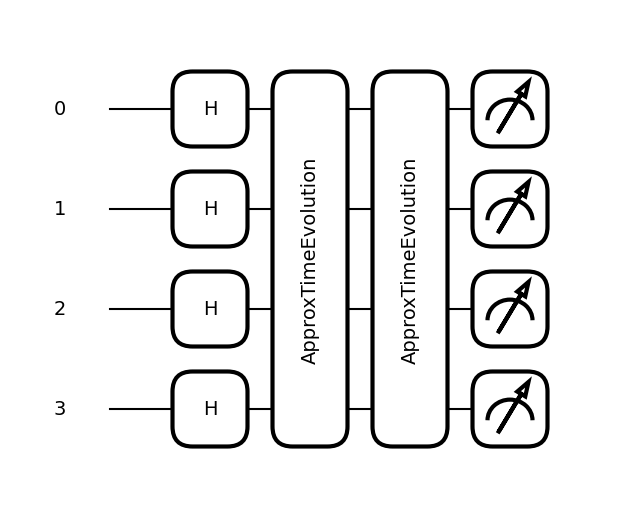

In [11]:
p = 1

def qaoa_layer(gamma, alpha):
    qaoa.cost_layer(gamma, cost_h)
    qaoa.mixer_layer(alpha, mixer_h)

@qml.qnode(dev)
def circuit(params, **kwargs):
    # Uniform superposition
    for wire in range(n_wires):
        qml.Hadamard(wires=wire)
    # p QAOA layers
    qml.layer(qaoa_layer, p , params[0], params[1])
    return qml.expval(cost_h)

# Preview circuit with random initial params
sample_params = np.array([[0.5] * p, [0.5] * p])
qml.draw_mpl(circuit)(sample_params)

## 5. Optimise with COBYLA

In [12]:
def cost_fn(flat_params):
    params = flat_params.reshape(2, p)
    return -circuit(params)   # negate: we minimise, QAOA maximises cut

np.random.seed(42)
x0 = np.random.uniform(0, 2 * np.pi, size=2 * p)

print("Optimising QAOA parameters...")
result = minimize(cost_fn, x0, method="COBYLA", options={"maxiter": 200, "rhobeg": 0.5})

opt_params = result.x.reshape(2, p)
opt_gamma, opt_alpha = opt_params[0], opt_params[1]
print(f"\nOptimised gamma: {opt_gamma}")
print(f"Optimised alpha: {opt_alpha}")
print(f"Max-Cut value (approx): {-result.fun:.4f}")

Optimising QAOA parameters...

Optimised gamma: [2.75070985]
Optimised alpha: [6.60930732]
Max-Cut value (approx): -2.3320


## 6. Sample the Optimal State & Visualise

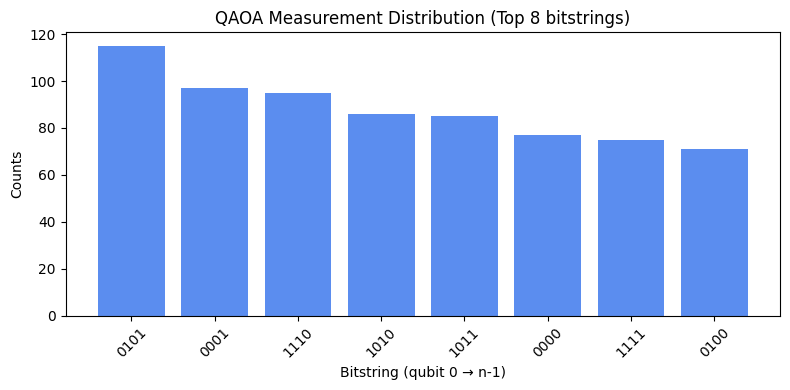


Best bitstring: 0101
Node partition: {0: 0, 1: 1, 2: 0, 3: 1}


In [13]:
@qml.qnode(dev)
def sample_circuit(params):
    for wire in range(n_wires):
        qml.Hadamard(wires=wire)
    qml.layer(qaoa_layer, p, params[0], params[1])
    return qml.sample()

samples = sample_circuit(opt_params)   # shape (shots, n_wires)

# Count bitstrings
from collections import Counter
bitstrings = ["".join(str(int(b)) for b in s) for s in samples]
counts = Counter(bitstrings)

top_k = 8
labels, freqs = zip(*counts.most_common(top_k))

plt.figure(figsize=(8, 4))
plt.bar(labels, freqs, color='#5B8DEF')
plt.xlabel("Bitstring (qubit 0 → n-1)")
plt.ylabel("Counts")
plt.title(f"QAOA Measurement Distribution (Top {top_k} bitstrings)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_bs = counts.most_common(1)[0][0]
partition = {i: int(best_bs[i]) for i in range(n_wires)}
print(f"\nBest bitstring: {best_bs}")
print(f"Node partition: {partition}")

## 7. (Optional) Running on Rigetti QPU via QCS

To switch to real hardware:
1. **Create a QCS account**: https://www.rigetti.com/get-quantum  
2. **Install the QCS CLI**: https://docs.rigetti.com/qcs/guides/using-the-qcs-cli  
3. **Log in**: `qcs auth login`  
4. Change `BACKEND = "qpu"` and `QPU_DEVICE` to an available QPU in Cell 3, then re-run.

Available QPUs can be listed with:
```python
from pyquil.api import list_quantum_computers
print(list_quantum_computers(qpus=True, qvms=False))
```

In [14]:
# List available Rigetti QPUs (requires QCS credentials)
try:
    from pyquil.api import list_quantum_computers
    qpus = list_quantum_computers(qpus=True, qvms=False)
    print("Available Rigetti QPUs:", qpus)
except Exception as e:
    print(f"Could not list QPUs (QCS credentials required): {e}")

Available Rigetti QPUs: ['Ankaa-3']
